Grover's algorithm in PennyLane

You are tasked with implementing Grover's search algorithm to find a specific target string within a search space. The specifications are as follows:

Boolean Oracle: Implement Grover's algorithm using a Boolean Oracle to find a target state from a dataset. For example, 8 numbers (from 0 to 7) can be encoded as quantum states using log2(8)=3 qubits. Note that an auxiliary qubit is also required to implement the Boolean Oracle. Refer to the Qiskit learning's section on Grover's Algorithm AND PennyLane codebook section on Grover's algorithm to learn about implementing Grover's algorithm. Build the oracle for marking the target state and then implement the subroutine of amplitude amplification to increase the success probability of the target state.

Write your code using PennyLane.

Scalability: Ensure your solution works for any number of qubits and any search string.

## Tasks

Implementation:
- Implement the Hadamard transform (to create superposition states required in the Grover circuit)
- Implement the boolean oracle to mark the target string.
- Implement a diffusion operator

Questions:
- How does the multi-controlled X gate help to mark the state?
- How can the oracle be generalized to mark multiple states?
- What is the role of phase kickback in the grover circuit?

Experiments:
- Run your algorithm to find the string "4" within a search space of integers from 0 to 7.
- Run your algorithm to find the string "18" within a search space of integers from 0 to 31.
- Answer the following questions for each of the cases:
    - How many qubits are needed for this search?
    - How many auxiliary qubits are required?
    - What is the ideal number of iterations?
    - Justify your answers based on the results obtained.


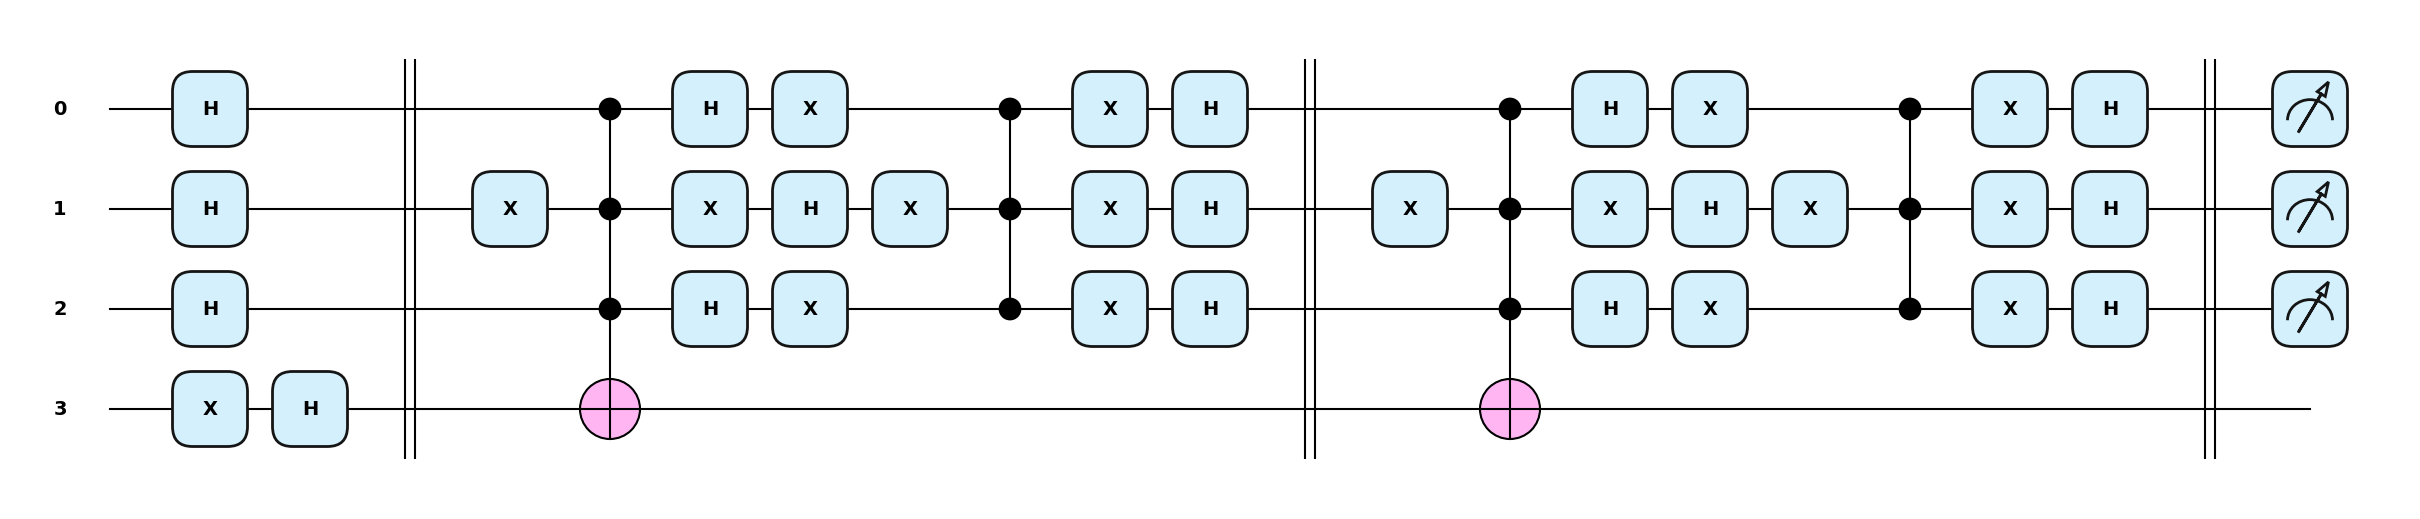

Probabilities: [0.0078 0.0078 0.0078 0.0078 0.0078 0.9453 0.0078 0.0078]
Most likely state index: 5 (Binary: 101)


In [23]:
import math
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt


def walsh_hadamard(n):
    """Applies the Walsh-Hadamard transform to n qubits."""
    for i in range(n):
        qml.Hadamard(wires=i)

def boolean_to_phase_oracle(n, secret_string, phase_ancilla):
    """Marks exactly one state using qml.ctrl to create a CX gate."""
    if isinstance(secret_string, str):
        secret_string = [int(bit) for bit in secret_string]
        
    # Apply PauliX to bits where the target string is 0
    for i in range(n):
        if secret_string[i] == 0:
            qml.PauliX(wires=i)
            
    qml.ctrl(qml.PauliX, control=list(range(n)))(wires=phase_ancilla)
    
    for i in range(n):
        if secret_string[i] == 0:
            qml.PauliX(wires=i)

def diffusion_operator(n):
    """Performs inversion about the mean using qml.ctrl to create a multi-controlled Z gate."""
    # Apply H and X to all query bits
    for i in range(n):
        qml.Hadamard(wires=i)
        qml.PauliX(wires=i)
        
    target_wire = n - 1
    control_wires = list(range(n - 1))
    
    qml.ctrl(qml.PauliZ, control=control_wires)(wires=target_wire)
    
    for i in range(n):
        qml.PauliX(wires=i)
        qml.Hadamard(wires=i)

def run_grovers_algorithm(n, secret_string, report_probs=False):
    total_wires = n + 1
    phase_ancilla = n 
    
    dev = qml.device('default.qubit', wires=total_wires)

    @qml.qnode(dev)
    def grover_circuit():
        # Initialize the phase ancilla to |-⟩ to enable phase kickback
        qml.PauliX(wires=phase_ancilla)
        qml.Hadamard(wires=phase_ancilla)
        
        walsh_hadamard(n)

        qml.Barrier(wires=range(total_wires))  
        # Apply Grover iterations
        iterations = math.floor((math.pi / 4) * math.sqrt(2**n))
        for _ in range(iterations):
            boolean_to_phase_oracle(n, secret_string, phase_ancilla)
            diffusion_operator(n)
            qml.Barrier(wires=range(total_wires)) 

        # Return probabilities for the query register only
        return qml.probs(wires=range(n))
    
    # Draw the circuit for visualization 
    fig, ax = qml.draw_mpl(grover_circuit, style='pennylane')()
    plt.show()


    
    circuit_probs = grover_circuit()
    if report_probs:
        most_likely_state = np.argmax(circuit_probs)
        print(f"Probabilities: {np.round(circuit_probs, 4)}")
        print(f"Most likely state index: {most_likely_state} (Binary: {bin(most_likely_state)[2:].zfill(n_qubits)})")

    return circuit_probs

# --- Example Execution ---
secret = "101" 
n_qubits = len(secret)

probs = run_grovers_algorithm(n_qubits, secret, report_probs=True)




Questions:
- How does the multi-controlled X gate help to mark the state?

The multi-controlled X gate applies an X operation if and only if all control qubits are in the state |1⟩. As we only want to activate the oracle for the target state, we first apply X gates on desired "zeroes" in the target string to flip them to "ones". This way, the multi-controlled X gate will only activate for the target state (as the target state will appear as all "ones" after the X gates), effectively marking it by flipping the phase of the target state. 

It's important to note that we must "unrotate" or "uncompute" the X gates after applying the multi-controlled X to restore the original state of the qubits, ensuring that only the target state has its phase flipped while all other states remain unchanged.


- How can the oracle be generalized to mark multiple states?

If we want to mark multiple states, we can apply multiple oracles sequentially, each designed to mark a different target state, before applying the diffusion operator. Therefore, if a state matches the criteria of any of the oracles, it will be marked (i.e., its phase will be flipped). 

- What is the role of phase kickback in the grover circuit?

Phase kickback is what ties everything together in Grover's algorithm. By initializing the ancilla qubit into state |-⟩, we can leverage the properties of the tensor product to utilize the Multi-Control-X gate as a "phase flipper". When the multi-controlled X identifies a target state, the following happens: 
$$
|x_{target}⟩ \otimes X|-⟩ = |x_{target}⟩ \otimes -|-⟩ = -|x_{target}⟩ \otimes |-⟩
$$

Otherwise, if the state is not the target state, the multi-controlled X does nothing and the state remains unchanged.

Hence, it is safe to apply this operation to the superposition of the input space, as the linear property ensures all components of the superposition will be processed, and the properties of the multi-controlled X ensure that only the target state(s) will have their phase flipped. We can then apply the diffusion operator to amplify the probability of measuring the target state(s). 



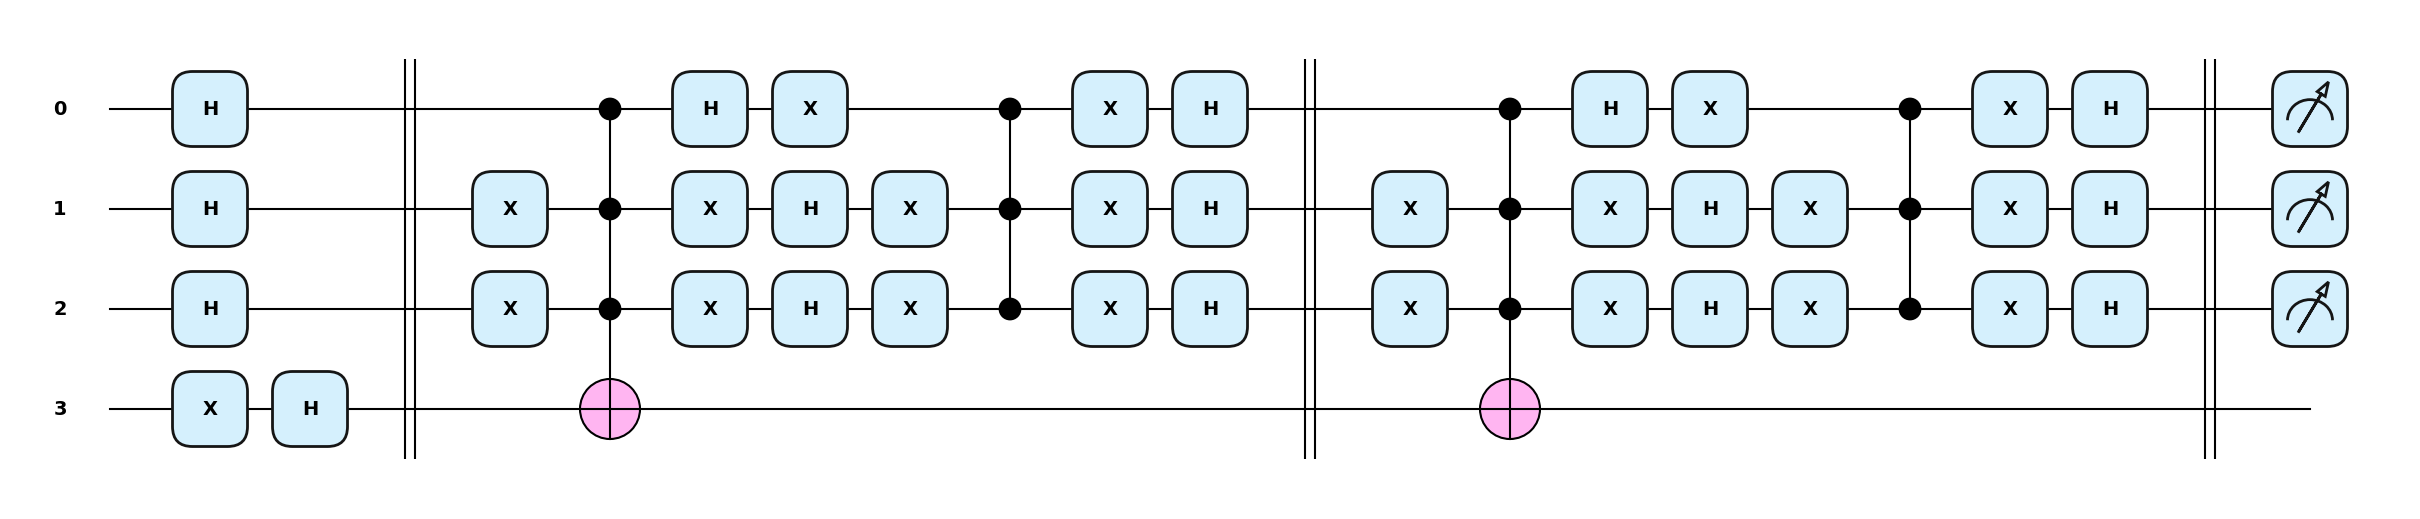

Probabilities: [0.0078 0.0078 0.0078 0.0078 0.9453 0.0078 0.0078 0.0078]
Most likely state index: 4 (Binary: 100)


In [24]:
# Experiment 1: Search for "4" in integers 0-7
secret_4 = "100"  # Binary representation of 4
n_qubits_4 = len(secret_4)
probs_4 = run_grovers_algorithm(n_qubits_4, secret_4, report_probs=True)

Discussion (Experiment 1): 
- How many qubits are needed for this search?
   
    We need 3 qubits, plus one more ancilla qubit. Hence, a total of 4 qubits are required.
- How many auxiliary qubits are required?
    
    We need 1 auxiliary qubit (the ancilla qubit) to implement the oracle.
- What is the ideal number of iterations?
    
    The ideal number of iterations is given by the formula: 
    $$
    k = \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \right\rfloor
    $$
    where N is the total number of states (8 in this case) and M is the number of target states (1 in this case). Hence, we have:
    $$
    k = \left\lfloor \frac{\pi}{4} \sqrt{\frac{8}{1}} \right\rfloor = 2
    $$
- Justify your answers based on the results obtained.

    My answers mirror both the circuit design and the experimental results. I used two iterations of the Grover Iterator, and I achieved a probability of approximately 0.94, which is close to the theoretical maximum of 1. This indicates that the number of iterations was effective in amplifying the probability of the target state. The number of qubits and auxiliary qubits used also align with the requirements for encoding the search space and implementing the oracle, confirming that the circuit was designed correctly for the problem at hand.

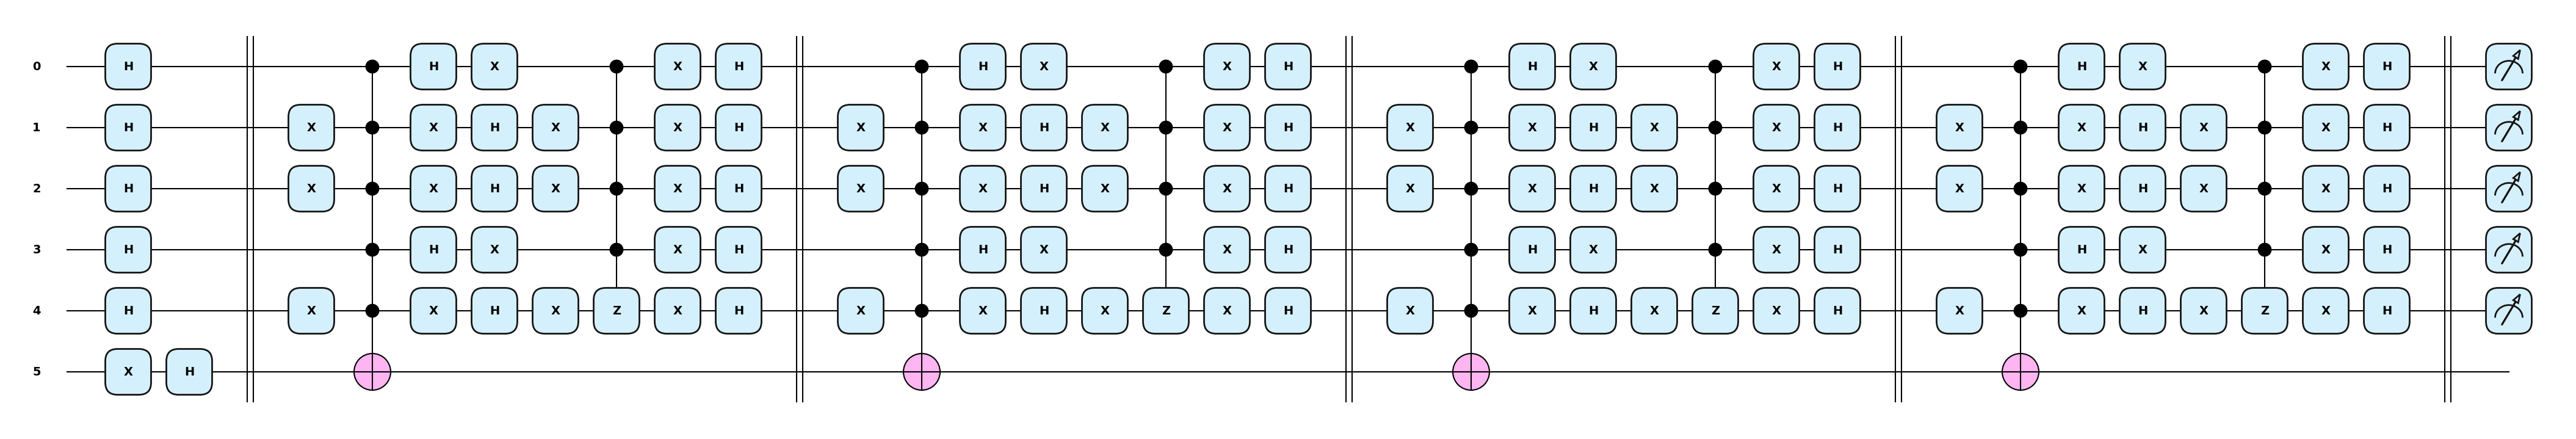

Probabilities: [0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.9992 0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.    ]
Most likely state index: 18 (Binary: 10010)


In [22]:
# Experiment 2: Search for "18" in integers 0-31
secret_18 = "10010"  # Binary representation of 18
n_qubits_18 = len(secret_18)
probs_18 = run_grovers_algorithm(n_qubits_18, secret_18, report_probs=True)

Discussion (Experiment 2): 
- How many qubits are needed for this search?

    We need 5 qubits, plus one more ancilla qubit. Hence, a total of 6 qubits are required.
- How many auxiliary qubits are required?
    
    We need 1 auxiliary qubit (the ancilla qubit) to implement the oracle.
- What is the ideal number of iterations?
    
    The ideal number of iterations is given by the formula: 
    $$
    k = \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \right\rfloor
    $$
    where N is the total number of states (32 in this case) and M is the number of target states (1 in this case). Hence, we have:
    $$
    k = \left\lfloor \frac{\pi}{4} \sqrt{\frac{32}{1}} \right\rfloor = 4
    $$

- Justify your answers based on the results obtained.

    My answers are consistent with both the circuit design and the experimental results. I used four iterations of the Grover Iterator, and I achieved a probability of approximately 0.9992, which is close to the theoretical maximum of 1. This indicates that the number of iterations was effective in amplifying the probability of the target state. The number of qubits and auxiliary qubits used also align with the requirements for encoding the search space and implementing the oracle, confirming that the circuit was designed correctly for the problem at hand.